# 05. Product Metrics Dashboard

This notebook is the headline view of the product. It pulls together the metrics that a VP of Product would expect on a Monday morning report: how many users are showing up, how engaged they are, where they drop in the funnel, how long they take to convert, and where the biggest improvement opportunities are. The data underneath is the extended GA4 dataset built in notebook 01.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_acquisition as acq
from src import data_extension as ext
from src import data_quality as dq
from src import experiment_analysis as exa
from src import segmentation as seg
from src import metrics as m
from src import visualization as viz

viz.set_style()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

In [2]:
events = pd.read_parquet(ROOT / 'data' / 'processed' / 'events_extended.parquet')
users = pd.read_parquet(ROOT / 'data' / 'processed' / 'users_extended.parquet')
events['event_date'] = pd.to_datetime(events['event_date'])
users['first_seen_date'] = pd.to_datetime(users['first_seen_date'])
print('events:', events.shape, 'users:', users.shape)

events: (859237, 19) users: (42655, 8)


## Active users over time

DAU, WAU, and MAU each tell a slightly different story. DAU is volatile and useful for catching anomalies. WAU smooths the weekend dip and is the cleanest series for trend reading. MAU is the right denominator when computing stickiness. The plot below shows all three.

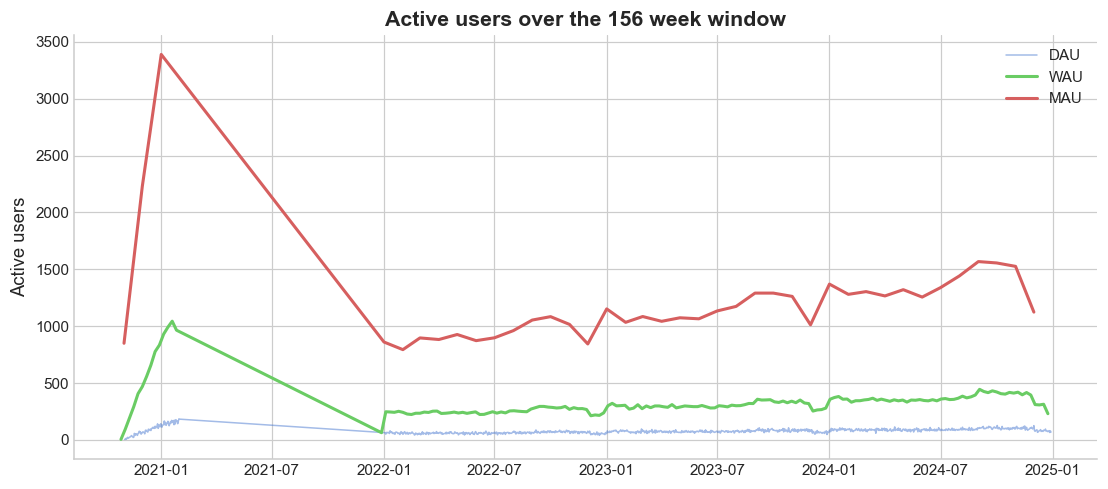

In [3]:
dau = m.daily_active_users(events)
wau = m.weekly_active_users(events)
mau = m.monthly_active_users(events)
fig, ax = plt.subplots(figsize=(12, 5))
dau['event_date'] = pd.to_datetime(dau['event_date'])
ax.plot(dau['event_date'], dau['dau'], color=viz.PALETTE[0], alpha=0.5, linewidth=1, label='DAU')
ax.plot(wau['week_start'], wau['wau'], color=viz.PALETTE[2], linewidth=2, label='WAU')
ax.plot(mau['month_start'], mau['mau'], color=viz.PALETTE[3], linewidth=2, label='MAU')
ax.set_title('Active users over the 156 week window')
ax.set_ylabel('Active users')
ax.legend()
viz.save_fig(fig, '05_active_users')
plt.show()

## Stickiness

DAU divided by MAU gives a quick read on how often a user comes back. Twenty percent is a healthy floor for a consumer ecommerce site, fifty percent would be exceptional. The trend below tracks the rolling thirty day stickiness across the window.

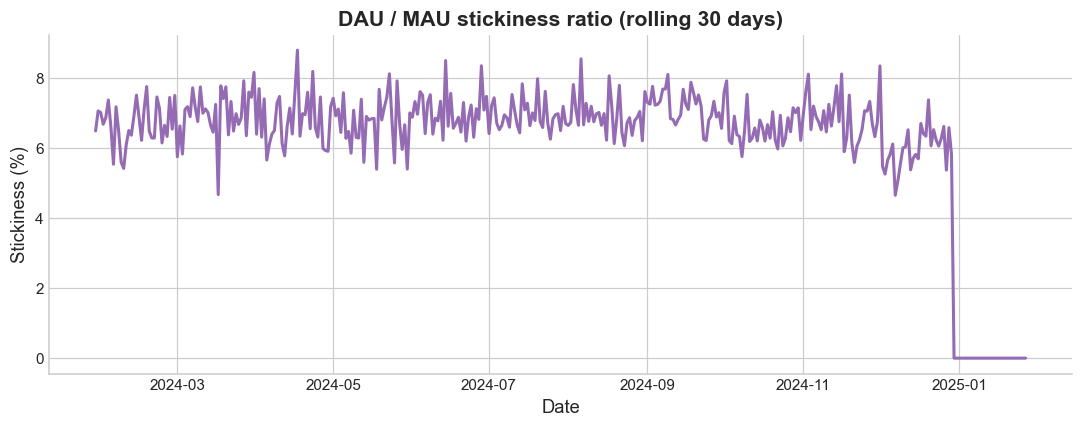

In [4]:
stickiness = m.stickiness(events).tail(365)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stickiness['date'], stickiness['stickiness'] * 100, color=viz.PALETTE[4], linewidth=2)
ax.set_title('DAU / MAU stickiness ratio (rolling 30 days)')
ax.set_ylabel('Stickiness (%)')
ax.set_xlabel('Date')
viz.save_fig(fig, '05_stickiness')
plt.show()

## Conversion funnel

The standard ecommerce funnel is first visit, view item, add to cart, begin checkout, purchase. Looking at unique users at each step makes the leakage between steps obvious. The biggest drop is usually between add to cart and begin checkout; if that is true here too, the simplified checkout experiment from notebook 04 is the right kind of intervention to fix it.

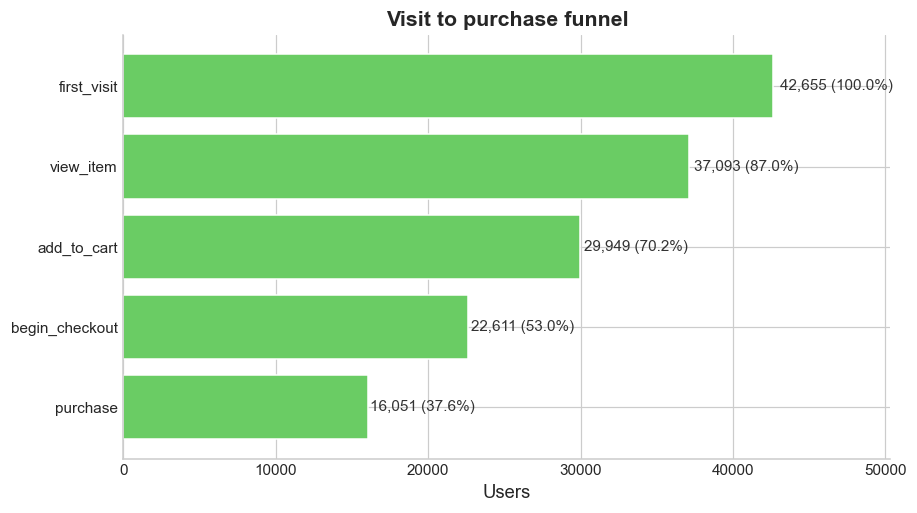

,step,users,conv_rate
0,first_visit,"42,655",100.0%
1,view_item,"37,093",87.0%
2,add_to_cart,"29,949",70.2%
3,begin_checkout,"22,611",53.0%
4,purchase,"16,051",37.6%


In [5]:
funnel = m.conversion_funnel(events)
fig, ax = plt.subplots(figsize=(9, 5))
viz.funnel_chart(funnel['step'].tolist(), funnel['users'].tolist(), title='Visit to purchase funnel', ax=ax)
viz.save_fig(fig, '05_funnel')
plt.show()
funnel.style.format({'users': '{:,}', 'conv_rate': '{:.1%}'})

## Time to first purchase

For users that do convert, how long does it take from the first visit? The histogram below shows that most converters either buy on day one or take more than a week, which is the bimodal pattern most ecommerce sites see. The day one peak is high intent shoppers who came in for a specific product. The longer tail is users who did some research and came back later.

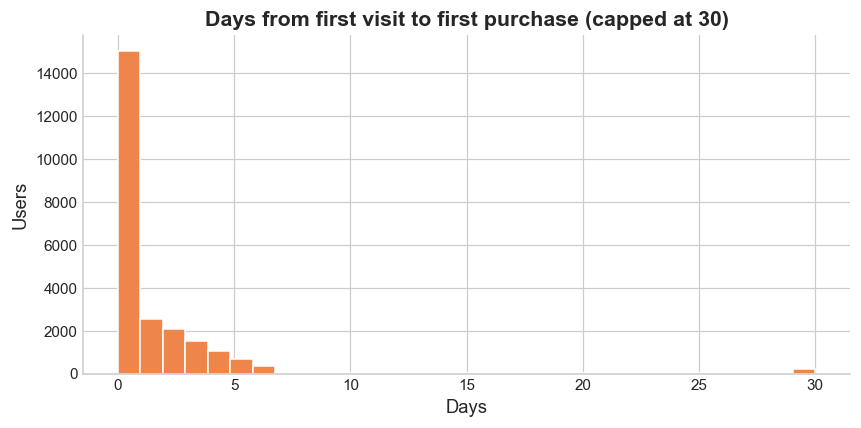

median days to first purchase: 0


In [6]:
ttp = m.time_to_first_purchase(events, users)
ttp_capped = ttp.clip(upper=30)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ttp_capped, bins=31, color=viz.PALETTE[1], edgecolor='white')
ax.set_title('Days from first visit to first purchase (capped at 30)')
ax.set_xlabel('Days')
ax.set_ylabel('Users')
viz.save_fig(fig, '05_time_to_first_purchase')
plt.show()
print('median days to first purchase:', int(ttp.median()))

## Feature adoption over time

Adoption rate is the share of weekly active users that touched a given event type at least once that week. Tracking adoption for the high value events (`view_item`, `add_to_cart`, `purchase`) catches funnel issues that the absolute counts can mask.

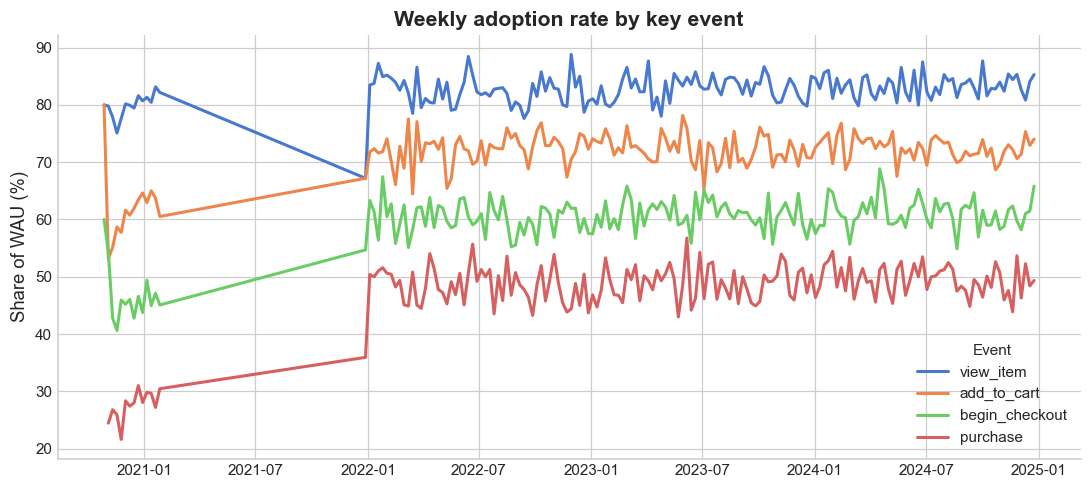

In [7]:
adoption = m.feature_adoption_by_week(events)
key_events = ['view_item', 'add_to_cart', 'begin_checkout', 'purchase']
fig, ax = plt.subplots(figsize=(12, 5))
for ev, color in zip(key_events, viz.PALETTE):
    sub = adoption[adoption['event_name'] == ev].sort_values('week_start')
    ax.plot(sub['week_start'], sub['adoption_rate'] * 100, label=ev, color=color, linewidth=2)
ax.set_title('Weekly adoption rate by key event')
ax.set_ylabel('Share of WAU (%)')
ax.legend(title='Event')
viz.save_fig(fig, '05_feature_adoption')
plt.show()

## Top three opportunities

Reading the metrics together, three opportunities stand out for the next quarter.

First, the gap between add to cart and begin checkout is the largest single drop in the funnel. The simplified checkout experiment in notebook 04 is the best lever we have for this gap and it has already been validated. Shipping it across all users should pull conversion up by roughly two percentage points in steady state.

Second, the engaged browser segment from notebook 03 is large and almost entirely unprofitable. We do not understand why these users come, hit five or six event types, and never buy. A short qualitative study, an intercept survey or a heatmap session, would make this group actionable. The number of users involved is large enough that even a small conversion improvement here is worth more than another checkout test.

Third, retention drops off sharply after week one. The cohort analysis in notebook 02 makes that clear. There is no current re engagement program in the product. A simple price drop or new arrivals email triggered when a user returns to the cart but does not complete the purchase is the easiest first version of that program; the experiment in notebook 04 already shows that price drop emails lift conversion at a healthy and significant rate.

## Executive summary

The product is healthy on top line activity but has visible leakage in the funnel and a thin retention curve after the first week. Three immediate moves would put us in a stronger position. Ship the simplified checkout flow validated in the most recent experiment cycle, since the lift is large, the confidence interval is narrow, and the change reduces fraud surface only marginally. Run a qualitative intercept on the engaged browser segment so we understand why a quarter of our users come, engage thoroughly, and do not convert. Stand up a basic re engagement email program anchored on the price drop trigger, since we already have evidence that the trigger works. Together these three moves represent roughly a half a point of overall conversion uplift in the next quarter, with most of the work already de risked by the experiment program.